In [1]:
import numpy as np

from matplotlib import pyplot as plt
import math

import random
from scipy.spatial import distance


import sys

In [2]:
def pdist2(x,y):
    return distance.cdist(x, [y], 'euclidean')[:,0]

def ismember(x,y,ax):
    out=np.array([]).astype(int);
    for i in y:
        tmp=np.where((x[:,0]==i[0])*(x[:,1]==i[1]))[0];
        out=np.concatenate((out, tmp), axis=0)
    return out;


In [38]:


def gsom(X,CR_init, sf_=0.85, gamma_=0.1, alpha_=0.9, max_neighborhood_radius_=4, 
             starting_learning_rate_=0.3, smoothing_learning_rate_factor_=0.5, 
             smoothing_neighborhood_radius_factor_=0.5,learning_itr_=50, 
             smoothing_itr_=50):

    
    data_size=X.shape[0]
    
    
    # 1) Initialization phase for GSOM
    SF=sf_; # spread factor
    gamma=gamma_; # factor of distribution; parameter for error distribution
    alpha=alpha_; # learning rate reduction
    max_neighborhood_radius=max_neighborhood_radius_ ; # starting value for the neihgborhood radius
    starting_learning_rate=starting_learning_rate_; # learning rate for growing phase
    smoothing_learning_rate_factor=smoothing_learning_rate_factor_;
    smoothing_neighborhood_radius_factor=smoothing_neighborhood_radius_factor_;

    learning_itr=learning_itr_; # grow for 50 iterations
    smoothing_itr=smoothing_itr_; # smooth for 50 iterations

    #b) Calculate the growth threshold (GT) for the given data set according to the user requirements.
    D=X.shape[1]; # number of features
    GT=-D*math.log(SF); # growth threshold

    #a) Initialize the weight vectors of the starting nodes (usually four) with random numbers.
    W=np.random.rand(4,D); # random weights
    CR=CR_init; # x; y coordinates on the grid for the initial 4 nodes
    #%plot(CR(:,1),CR(:,2), 'o'); % plot coordinates of nodes
    TE=np.zeros(CR.shape[0]); # will store error values for each node



    # 2) Growing phase. Check iterations they start from 0 here
    learning_rate = starting_learning_rate; # initial learning rate


    fig, ax = plt.subplots()


    for iter in range (1,learning_itr+1):
    
        # smooth for several iterations %h) Repeat steps b)–g) until all inputs have been presented and node growth is reduced to a minimum level.
    
        # update neighborhood radius
        time_constant= learning_itr/math.log(max_neighborhood_radius); # used in update
        neighborhood_radius = max_neighborhood_radius*math.exp(-(iter-1)/ time_constant );
    
        ind = np.random.choice(data_size,data_size, replace=False) ; # shuffle the dataset
        X_new=X[ind,:]
    
        for ex in range(data_size): 
            # for all examples in the dataset

            x=X_new[ex,:]; # take current example
        
            #a) Present input to the network.
            #b) Determine the weight vector that is closest to the input vector mapped to the current feature map (winner), using Euclidean distance (similar to the SOM).
            winner=np.argmin(pdist2(W, x));
        
            #d) Increase the error value of the winner (error value is the difference between the input vector and the weight vectors).
            TE[winner] = TE[winner] +  np.sqrt(np.sum(np.power(x - W[winner,:],2)));
        
            #c) The weight vector adaptation is applied only to the neighborhood of the winner and the winner itself.
            dist_grid=pdist2(CR, CR[winner,:]); # euclidean distance from winner to all other nodes
        
            dist_grid_neig=np.where(dist_grid<=neighborhood_radius)[0]; # indices within neighborhood
        
            for i in range(dist_grid_neig.shape[0]): 
                # for all nodes in the neighborhood
                influence = math.exp(-(np.power(dist_grid[i],2))/(2*( neighborhood_radius**2 )) ); # calculate the influence of a given node
                W[dist_grid_neig[i],:]= W[dist_grid_neig[i],:] +  learning_rate * influence* ( x -  W[dist_grid_neig[i],:] ) ;  # modify the weight of a given node
        
        
        
            #e) When TE<GT (where is the total error of node and GT is the growth threshold).
            dist_grid_neig=np.where(dist_grid==1)[0];#indices of immediate neighbors
            dir_neig= np.sum(pdist2(CR,  CR[winner,:] )==1); # returns the number of immediate members
            if TE[winner]> GT:
                # need to grow a node
                if dir_neig==4:
                    #Distribute weights to neighbors if is a nonboundary node.
                    TE[winner]= GT/2;  # equation (6) in the paper
                    # distribute error to neighbors
                    for i in range (dist_grid_neig.shape[0]):
                        TE[dist_grid_neig[i]] = TE[dist_grid_neig[i]] + gamma*  TE[dist_grid_neig[i]]; # equation (7) in the paper
                
                else: 
                    # boundary node
                    #Grow nodes if it is a boundary node.
                    dir_neig_coor= CR[dist_grid_neig,:]; # coordinates of direct neighbors
                
                    nodes_candidates= np.array([ [CR[winner,0]+1 , CR[winner,1] ],
                                                [CR[winner,0]-1 , CR[winner,1] ],
                                                [CR[winner,0]    , CR[winner,1]+1],
                                                [CR[winner,0]    , CR[winner,1]-1 ] ]); # coordinates of potential new nodes
                
                    prune=ismember(nodes_candidates,dir_neig_coor,'rows'); # indices of candidates to be pruned
                    nodes_candidates=np.delete(nodes_candidates,prune,0); # delete already existing nodes
                    #CR=[CR; nodes_candidates]; # add coornidates of new nodes to CR
                    #TE=[TE;zeros(length(nodes_candidates(:,1)),1)]; # initialize error counters for new nodes
                    
                
                    #f) Initialize the new node weight vectors to match the neighboring node weights.
                    winner_coor=CR[winner,:]; # coordinates of the winner node
                
                    # check first for the cases when new node is in between two older nodes
                    check=np.zeros(nodes_candidates[:,0].shape).astype(int); #will set the results of check
                    check_nodes=np.zeros(nodes_candidates[:,0].shape).astype(int);
                
                    for i in range(nodes_candidates[:,1].shape[0]):
                    
                        new_node_cr=nodes_candidates[i,:]; # coordinates of a new node
                    
                        # find which axis is the same and coordinate of a node to check
                        if new_node_cr[0] == winner_coor[0]: 
                            # x is the same
                            if winner_coor[1] > new_node_cr[1]:
                                old_node = np.array([new_node_cr[0], new_node_cr[1]-1]) 
                            else:
                                old_node = np.array([new_node_cr[0], new_node_cr[1]+1])
                        elif new_node_cr[1] == winner_coor[1]: 
                            # y is the same
                            if winner_coor[0] > new_node_cr[0]:
                                old_node = np.array([new_node_cr[0]-1, new_node_cr[1]]) ;
                            else:
                                old_node = np.array([new_node_cr[0]+1, new_node_cr[1]]) ;
                        
                    
                        old_node_ind=ismember(CR,[old_node],'rows');
                        #old_node_ind contains (one) index  in CR  for "old_node"
                                                
                        if old_node_ind.size!=0: # not empty old_node_ind - the node is in SOM
                            check[i]=1; # set flag to one
                            check_nodes[i]=old_node_ind; # store the index of that node
                    
                
                    # if there are such cases add these nodes to SOM
                    if np.sum(check)>0:
                        check_ind=np.where(check)[0];
                        for i in range(check_ind.size): # for all cases
                            w= 0.5*( W[winner,:] + W[check_nodes[check_ind[i]],:]) ; # create initial weight vector
                            #W(end+1,:)=w; %update W
                            W=np.concatenate((W,[w]), axis=0)                        
                            CR=np.concatenate((CR, [nodes_candidates[check_ind[i]]]), axis=0);  #update CR with that candidate
                            TE=np.append(TE, 0); # % initialize error counter for new node
                        nodes_candidates=np.delete(nodes_candidates,check_ind,0)
                    
                    # Second, check  for the cases when new node is within a % straing line
                    
                    check=np.zeros(nodes_candidates[:,0].shape).astype(int); #will set the results of check
                    check_nodes=np.zeros(nodes_candidates[:,0].shape).astype(int);
                
                    for i in range(nodes_candidates[:,1].shape[0]):
                        new_node_cr=nodes_candidates[i,:]; # coordinates of a new node
                    
                        # find which axis is the same and coordinate of a node to check
                        if new_node_cr[0] == winner_coor[0]:  # x is the same
                            if winner_coor[1] > new_node_cr[1]:
                                old_node = np.array([new_node_cr[0], new_node_cr[1]+2]) ;
                            else:
                                old_node = np.array([new_node_cr[0], new_node_cr[1]-2]) ;
                        elif new_node_cr[1] == winner_coor[1]: # y is the same
                            if winner_coor[0] > new_node_cr[0]:
                                old_node = np.array([new_node_cr[0]+2, new_node_cr[1]]) ;
                            else:
                                    old_node = np.array([new_node_cr[0]-2, new_node_cr[1]]) ;        
                    
                        old_node_ind=ismember(CR,[old_node],'rows');
                            #old_node_ind contains (one) index  in CR  for "old_node"
                                                
                        if old_node_ind.size!=0: # not empty old_node_ind - the node is in SOM
                            check[i]=1; # set flag to one
                            check_nodes[i]=old_node_ind; # store the index of that node
                    
                
                        # if there are such cases add these nodes to SOM
                    if np.sum(check)>0:
                        check_ind=np.where(check)[0];
                    
                        for i in range(check_ind.size): # for all cases
                            w= 2*W[winner,:] - W[check_nodes[check_ind[i]],:] ; # create initial weight vector
                            #W(end+1,:)=w; %update W
                            W=np.concatenate((W,[w]), axis=0)                        
                            CR=np.concatenate((CR, [nodes_candidates[check_ind[i]]]), axis=0);  #update CR with that candidate
                            TE=np.append(TE, 0); # % initialize error counter for new node
                        nodes_candidates=np.delete(nodes_candidates,check_ind,0)
                   # nodes_candidates( check ,:) = []; % remove candidates from the list
                   #double check delition abouive! chedk!
                                                
                   # Third, check that there are two node are left and treat
                   # them sequentially
                    if nodes_candidates.size!=0:
                        if nodes_candidates[:,1].size == 2:
                            # initialize one node as side an one as line
                            w= 2*W[winner,:] -  W[-1,:] ;  #  the most recent node should be linearly added
                            W=np.concatenate((W,[w]), axis=0)                        
                            CR=np.concatenate((CR, [nodes_candidates[0]]), axis=0);  #update CR with that candidate
                            TE=np.append(TE, 0); # % initialize error counter for new node
                            nodes_candidates=np.delete(nodes_candidates,0,0) #remove the candidate from the list
                            #initialize the other node as straight using the
                            # previous one
                            w= 2*W[winner,:] -  W[-1,:] ;  #  the most recent node should be linearly added
                            W=np.concatenate((W,[w]), axis=0)                        
                            CR=np.concatenate((CR, [nodes_candidates[0]]), axis=0);  #update CR with that candidate
                            TE=np.append(TE, 0); # % initialize error counter for new node
                            nodes_candidates=np.delete(nodes_candidates,0,0) #remove the candidate from the list

                        else:
                            print('oops. something is wrong in logic\n')

                # Note that using time.sleep does *not* work here!
                #plt.pause(0.001)

                #plt.plot([],[])
                
               
    #                fig.canvas.draw()
#                plt.show()
                #time.sleep(0.1)
#        ax.cla()
#        plt.xlim([-20,20])
#        plt.ylim([-20,20])

#        ax.plot(CR[:,0],CR[:,1],'o', mfc='none')
#        ax.set_title("iteration {}".format(iter))
#        plt.pause(0.01)

        #plt.close()
            
            # g) Initialize the learning rate LR to its starting value.
            #Therefore, during the growing phase, the GSOM initializes the learning rate and the neighborhood size to a starting value at each new input.
            # update learning rate
    
        nodes_tot=CR.shape[0]
        phi_n=(1- (3.8/ nodes_tot )) ; # learning rate reduction
        learning_rate = learning_rate* phi_n * alpha; # update learning rate, which would be used at the next iteration
 
    # 3) Smoothing phase.

    learning_rate = starting_learning_rate * smoothing_learning_rate_factor; # initial learning rate
    reduced_neighborhood_radius = max_neighborhood_radius * smoothing_neighborhood_radius_factor; # a) fix a small starting neighborhood.


    for iter in range(1,smoothing_itr+1): # smooth for several iterations
        ind = np.random.choice(data_size,data_size, replace=False) ; # shuffle the dataset
        X_new=X[ind,:]
    
       # update neighborhood radius
        time_constant= smoothing_itr/math.log(reduced_neighborhood_radius); # used in update
        neighborhood_radius = reduced_neighborhood_radius*math.exp(-(iter-1)/ time_constant );
    
        for ex in range(data_size): # for all examples in the dataset
            x=X_new[ex,:]; # take current example
            # b) Find winner and adapt the weights of winner and neighbors in the same way as in growing phase.
            winner=np.argmin(pdist2(W, x));
        

        
            #c) The weight vector adaptation is applied only to the neighborhood of the winner and the winner itself.
            dist_grid=pdist2(CR, CR[winner,:]); # euclidean distance from winner to all other nodes
        
            dist_grid_neig=np.where(dist_grid<=1)[0]; # indices within direct neighborhood

        
            for i in range(dist_grid_neig.size): # update only itself and direct neighbors
                influence = math.exp(-(dist_grid[i]**2)/(2*( neighborhood_radius**2 )) ); # calculate the influence of a given node
                W[dist_grid_neig[i],:]= W[dist_grid_neig[i],:] +  learning_rate * influence* ( x -  W[dist_grid_neig[i],:] ) ;  #€ modify the weight of a given node
       
   
        #a) Reduce learning rate
        nodes_tot=CR.shape[0]; # current total number of nodes
        phi_n=(1- (3.8/ nodes_tot )) ; # learning rate reduction
        learning_rate = learning_rate* phi_n * alpha; # update learning rate, which would be used at the next iteration

    return CR, W

In [34]:
#================Set rng========================
#set seed for rng
seed=random.randint(1, 1000)

random.seed(seed)

In [25]:
#===============Reading data====================
import pandas as pd
def parse_input_zoo_data(filename, header='infer'):

    input_data = pd.read_csv(filename, header=header)

    classes = input_data[17].tolist()
    labels = input_data[0].tolist()
    arr=input_data.values;
    input_database = {
        #take features 2-17 as in the paper GSOM
        0: arr[:,2:17]
    }

    return input_database, labels, classes

input_filename = 'data/zoo.txt'
data_vec, labels, classes = parse_input_zoo_data(input_filename,None)


In [29]:
# 1) Initialization phase for GSOM
dimensions=data_vec[0].shape[1]; # dimensionality of the weight vectors (num features)
SF=0.85; # spread factor
gamma=0.1; # factor of distribution; parameter for error distribution
alpha=0.9; # learning rate reduction
max_neighborhood_radius=4 ; # starting value for the neihgborhood radius
starting_learning_rate=0.3; # learning rate for growing phase
smoothing_learning_rate_factor=0.5;
smoothing_neighborhood_radius_factor=0.5;

learning_itr=50; # grow for 50 iterations
smoothing_itr=50; # smooth for 50 iterations

hit_threshold_fraction=0.05

data_size=data_vec[0].shape[0]

hit_threshold = math.ceil(data_size * hit_threshold_fraction);




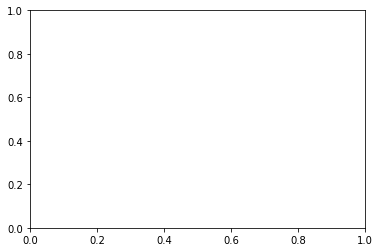

In [39]:
SOM_=np.array([[0, 0], [0, 1], [1, 0], [1, 1]]); # x; y coordinates on the grid for the initial 4 nodes

## FOR BETTER performance comment out itrerative plotting of GSOMs in gsom.py file!

SOM_, W_SOM_= gsom(data_vec[0], SOM_, sf_=SF, gamma_=gamma, alpha_=alpha, max_neighborhood_radius_=max_neighborhood_radius, 
             starting_learning_rate_=starting_learning_rate, smoothing_learning_rate_factor_=smoothing_learning_rate_factor, 
             smoothing_neighborhood_radius_factor_=smoothing_neighborhood_radius_factor,
             learning_itr_=learning_itr, 
             smoothing_itr_=smoothing_itr);






SUCCESS! GSOM is done. Now plotting the result



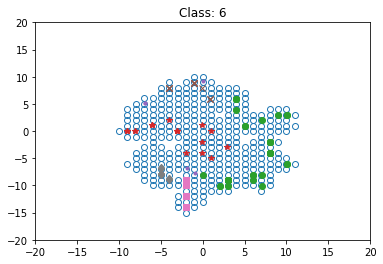

In [32]:
print("SUCCESS! GSOM is done. Now plotting the result\n")
# Depict something
fig1, ax1 = plt.subplots()
ax1.cla()
plt.xlim([-20,20])
plt.ylim([-20,20])

ax1.plot(SOM_[:,0],SOM_[:,1],'o', mfc='none')
ax1.set_title("Result ")

winners=np.zeros(data_size)

for ex in range(data_size): 
    # for all examples in the dataset

    x=data_vec[0][ex,:]; # take current example
        
        #a) Present input to the network.
        #b) Determine the weight vector that is closest to the input vector mapped to the current feature map (winner), using Euclidean distance (similar to the SOM).
    winners[ex]=np.argmin(pdist2(W_SOM_, x));


markers=['+', 'o', '*', '.', 'x',	's', 'd' ];


#label=table2array(M(:,18)); % get only 16 features as in the paper
#figure()
#hold on

def awgn(in_, snr):
    noise = np.random.normal(0, 0.1);
    return in_+noise;
 
classes=np.asarray(classes);
for i in range(7):
    
    
    ind_class=np.where(classes==i)[0].astype(int);
    ind_class_nodes=winners[ind_class].astype(int);
    ind_class_nodes= SOM_[ind_class_nodes,: ].astype(int);    
    #ax1.plot(ind_class_nodes[:,0], ind_class_nodes[:,1], markers[i]  )
    ax1.plot(awgn(ind_class_nodes[:,0] ,10), awgn(ind_class_nodes[:,1] ,10), markers[i]  )
    
    plt.xlim([-20,20])
    plt.ylim([-20,20])
    ax1.set_title("Class: {}".format(i))

